# Análisis de Ventas - YvexIQ demo
## Introducción
Este análisis explora los datos de venta de una tienda de ropa para responder a las siguientes preguntas de negocio:
- ¿Cuál ha sido la evolución de las ventas?
- ¿Que productos y departamentos generan mas ingresos y tienen mas rentabilidad?
- ¿Cómo son mis clientes?
- ¿Tengo problemas con las devoluciones?

Este análisis tiene como objetivo principal dar una idea del rendimiento que ha tenido la tienda y detectar mediante machine learning las características que determinan porque un producto se devuelve y como podriamos evitar e impedir que se devuelva un producto.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from db_connector import conectar

## 1. Carga y exploración inicial de datos

In [2]:
engine = conectar()

tickets = pd.read_sql("SELECT * FROM tickets_clean", engine)
productos = pd.read_sql("SELECT * FROM productos_clean", engine)
clientes = pd.read_sql("SELECT * FROM clientes_clean", engine)
devoluciones = pd.read_sql("SELECT * FROM devoluciones_clean", engine)
ticket_productos = pd.read_sql("SELECT * FROM ticket_productos_clean", engine)
departamentos = pd.read_sql("SELECT * FROM departamentos_clean", engine)

print("Datos cargados correctamente")
print(f"Tickets: {len(tickets)} registros")
print(f"Productos: {len(productos)} registros")
print(f"Clientes: {len(clientes)} registros")
print(f"Devoluciones: {len(devoluciones)} registros")
print(f"Departamentos: ´{len(departamentos)} registros")

Datos cargados correctamente
Tickets: 30000 registros
Productos: 400 registros
Clientes: 200 registros
Devoluciones: 1500 registros
Departamentos: ´10 registros


### Exploración inicial

In [3]:
tickets.head()

,id,cliente_id,total,ganancia,fecha,numero_articulos,metodo_pago,canal,operador_codigo
0,1,NaN,309.20,131.34,2024-03-30,4,bizum,tienda_fisica,OP-939
1,2,131.0,143.23,56.87,2025-02-12,3,efectivo,telefono,OP-222
2,3,132.0,468.53,216.98,2025-09-16,5,efectivo,tienda_fisica,OP-368
3,4,NaN,404.99,85.05,2024-12-23,1,transferencia,tienda_fisica,OP-843
4,5,111.0,461.29,105.52,2024-09-18,3,transferencia,tienda_fisica,OP-725


In [4]:
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                30000 non-null  int64  
 1   cliente_id        23961 non-null  float64
 2   total             30000 non-null  float64
 3   ganancia          30000 non-null  float64
 4   fecha             30000 non-null  str    
 5   numero_articulos  30000 non-null  int64  
 6   metodo_pago       30000 non-null  str    
 7   canal             30000 non-null  str    
 8   operador_codigo   30000 non-null  str    
dtypes: float64(3), int64(2), str(4)
memory usage: 3.1 MB


In [5]:
porcentaje_anonimos = tickets['cliente_id'].isnull().mean() * 100
print(f"{porcentaje_anonimos:.1f}% de las ventas son de clientes anónimos")

20.1% de las ventas son de clientes anónimos


**insight** el 20.1% de las ventas que se realizan provienen de clientes anónimos. Por lo que existe una buena oportunidad de mejora en captación y fidelización de clientes.

## 2. Análisis de ventas

In [6]:
tickets['fecha'] = pd.to_datetime(tickets['fecha'])
ventas_mensuales = tickets.groupby(tickets['fecha'].dt.to_period('M'))['total'].sum()
print(ventas_mensuales)

fecha
2023-01    213893.72
2023-02    199524.01
2023-03    221371.41
2023-04    211029.18
2023-05    224304.93
2023-06    217651.42
2023-07    210536.43
2023-08    205380.14
2023-09    191637.15
2023-10    219800.42
2023-11    203246.94
2023-12    209746.69
2024-01    211301.33
2024-02    211576.45
2024-03    231090.47
2024-04    222498.43
2024-05    204107.73
2024-06    211770.29
2024-07    211259.52
2024-08    220613.98
2024-09    218601.06
2024-10    216019.06
2024-11    204226.36
2024-12    214720.73
2025-01    240066.32
2025-02    198340.42
2025-03    220089.14
2025-04    202965.25
2025-05    208045.02
2025-06    205286.42
2025-07    205393.05
2025-08    232250.95
2025-09    214887.00
2025-10    207611.15
2025-11    206551.41
2025-12    209972.51
Freq: M, Name: total, dtype: float64


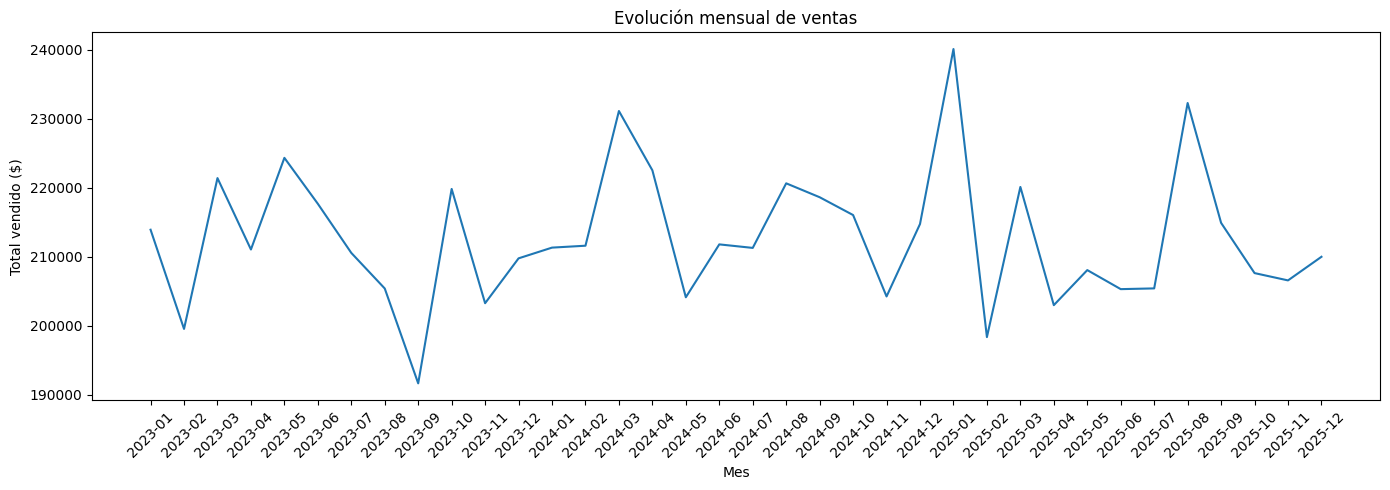

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(ventas_mensuales.index.astype(str), ventas_mensuales.values)
plt.title("Evolución mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Total vendido ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
- Septiembre 2023 fue el peor mes del período analizado
- Las ventas muestran un patrón irregular con picos y bajadas frecuentes — no hay una tendencia clara de crecimiento sostenido
- Enero 2025 fue el mejor mes registrado, seguido de una caída considerable en febrero 2025
- Las ventas se mantienen relativamente estables entre 190,000 y 240,000 mensuales

## 3. Análisis de productos

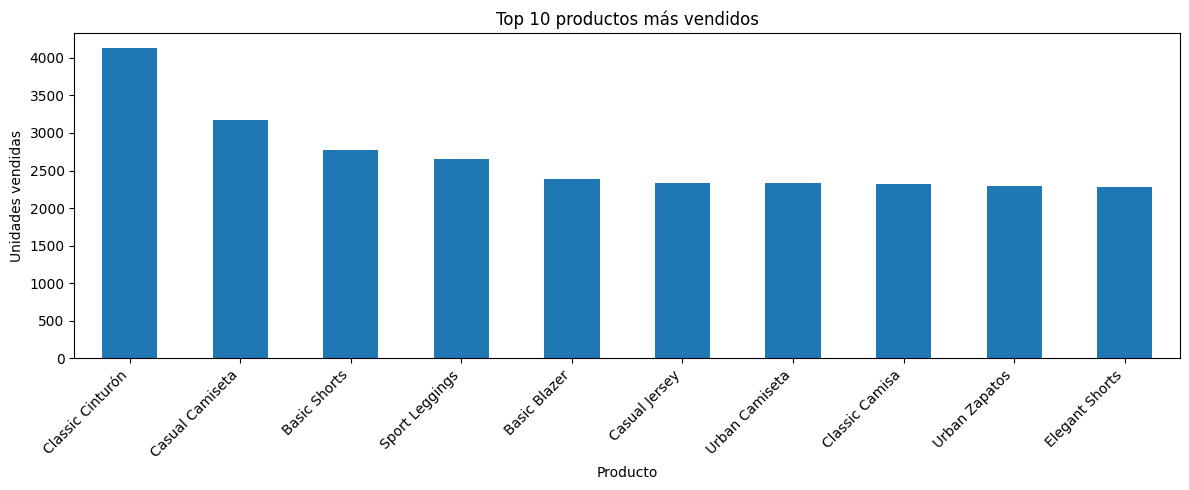

In [8]:
union = pd.merge(ticket_productos, productos, left_on='producto_id', right_on='id')
top_productos = union.groupby('descripcion')['cantidad'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
top_productos.plot(kind='bar')
plt.title("Top 10 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
- El producto más vendido es Classic Cinturón con 4,127 unidades, casi el doble que el segundo producto mas vendido.
- Los accesorios y ropa básica dominan el top 10
- No hay un producto claramente dominante después del primero ya que el resto están relativamente igualados.

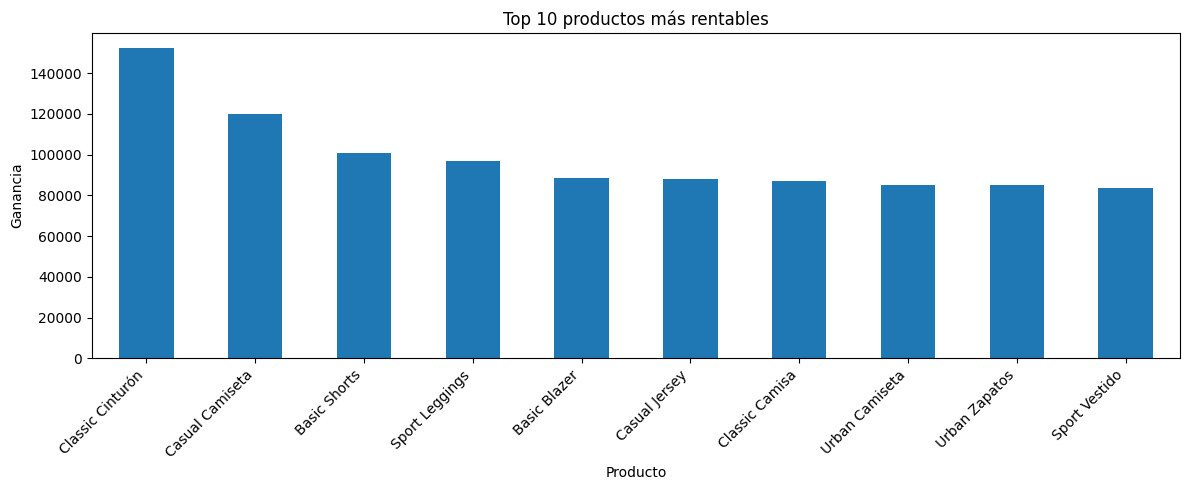

In [9]:
top_productos_rentabilidad = union.groupby('descripcion')['ganancia'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
top_productos_rentabilidad.plot(kind='bar')
plt.title("Top 10 productos más rentables")
plt.xlabel("Producto")
plt.ylabel("Ganancia")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
- El ranking de rentabilidad coincide casi exactamente con el de unidades vendidas.
- Classic Cinturón no solo es el más vendido sino también el más rentable siendo el producto estrella de forma clara.
- Sport Vestido aparece en rentabilidad pero no en unidades, por lo que tiene mejor margen por unidad.

### Análisis por departamento

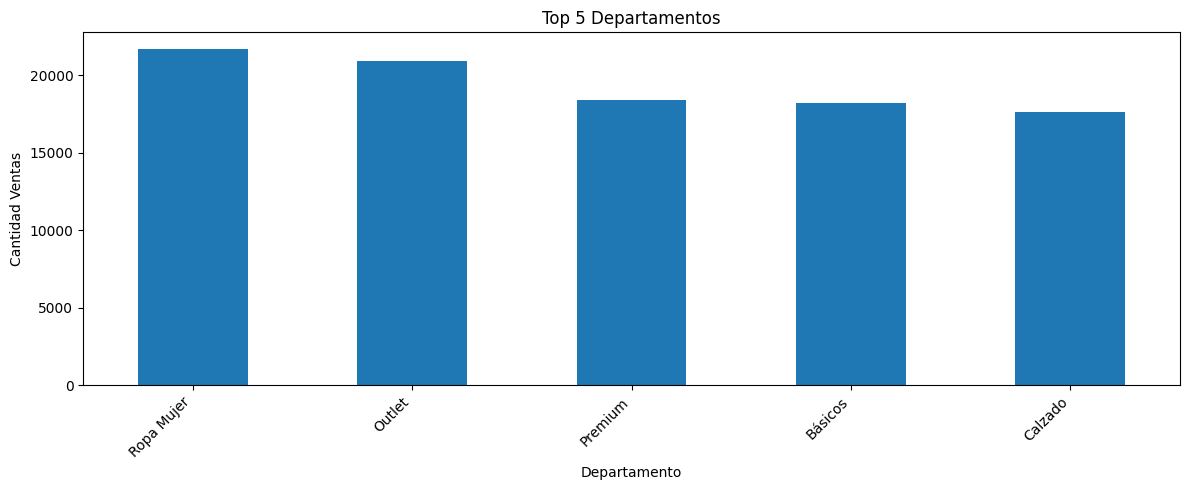

In [10]:
union_departamentos = pd.merge(departamentos, union, left_on='id', right_on='departamento_id')
top_departamentos = union_departamentos.groupby('nombre')['cantidad'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(12, 5))
top_departamentos.plot(kind='bar')
plt.title("Top 5 Departamentos")
plt.xlabel("Departamento")
plt.ylabel("Cantidad Ventas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
- "Ropa Mujer" es el departamento más vendido con 21,688 unidades.
- "Outlet" tiene ventas muy cercanas a Ropa Mujer por lo que se puede deducir que los clientes buscan ofertas.
- Los departamentos están relativamente equilibrados y no hay ninguno muy dominante por encima del resto.

## 4. Análisis de clientes

pais
Gambia          4
El Salvador     4
Guadeloupe      3
Tailandia       3
Nauru           3
Uganda          3
Portugal        3
Kiribati        3
Sierra Leone    2
Burkina Faso    2
Name: count, dtype: int64


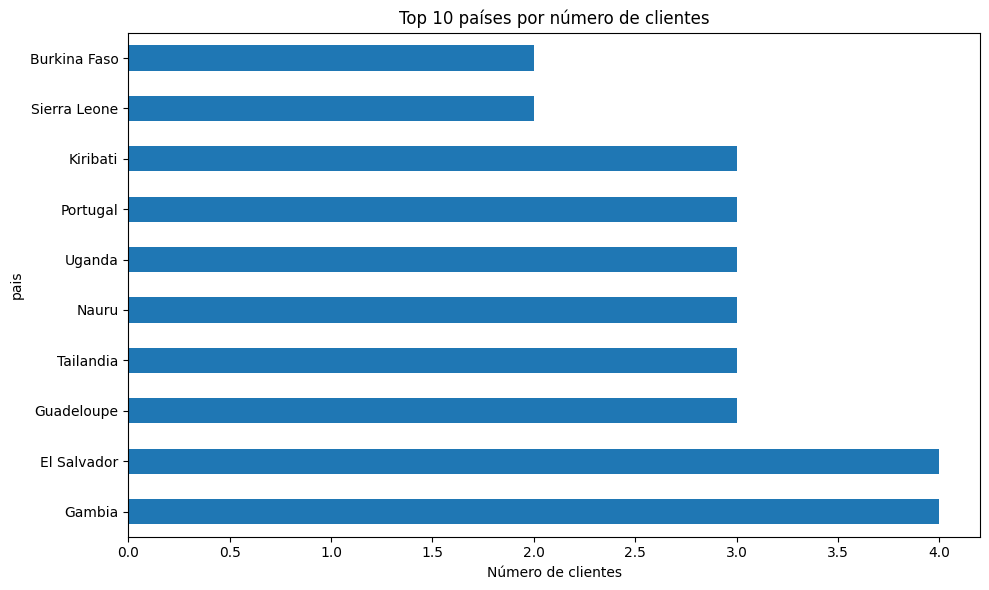

In [11]:
clientes_pais = clientes['pais'].value_counts().head(10)
print(clientes_pais)
plt.figure(figsize=(10, 6))
clientes_pais.plot(kind='barh')
plt.title("Top 10 países por número de clientes")
plt.xlabel("Número de clientes")
plt.tight_layout()
plt.show()

**Nota:** La distribución geográfica está muy dispersa debido al tamaño reducido de la base de datos demo (200 clientes). En un escenario real con más clientes se esperaría mayor concentración en ciertos mercados.

In [12]:
clientes['total_gastado'].describe()

count     175.000000
mean     2539.468571
std      1392.240125
min        52.130000
25%      1446.845000
50%      2456.160000
75%      3805.430000
max      4973.780000
Name: total_gastado, dtype: float64

**Insights:**

- El gasto medio por cliente es 2,539
- El gasto por cliente tiene una gran variacion que va desde un minimo de 52 a un máximo de 4974
- El 50% de los clientes gasta menos de 2,456
- 25 clientes (12.5%) no tienen compras registradas.

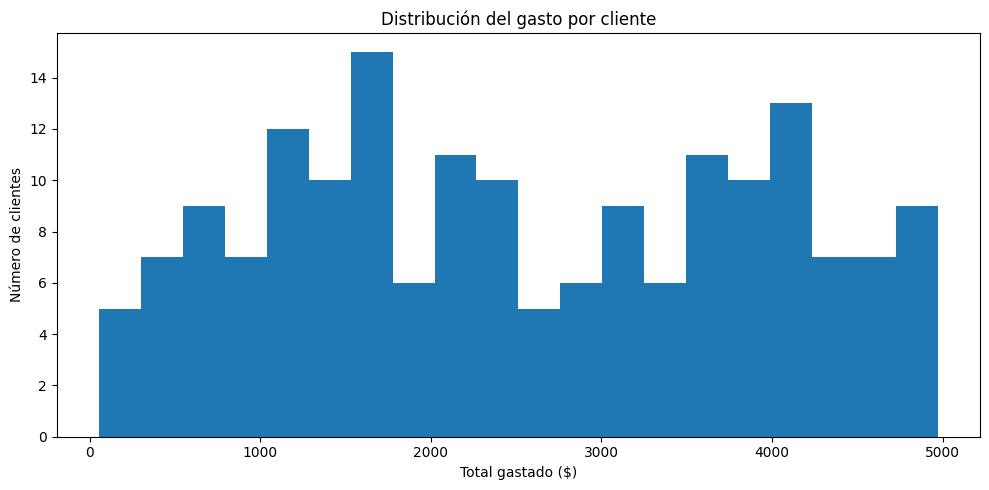

In [13]:
plt.figure(figsize=(10, 5))
clientes['total_gastado'].dropna().plot(kind='hist', bins=20)
plt.title("Distribución del gasto por cliente")
plt.xlabel("Total gastado ($)")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

**Insights:**
- La distribución del gasto no es completamente uniforme ya que se puede apreciar dos grupos de clientes.
- **Clientes medios:** Concentrados entre 1,000 y 2000 unidades monetarias, es el grupo más numeroso.
- **Clientes de "alto valor":** Segundo pico cerca de 4,000, grupo sorprendentemente grande.
- Esto sugiere una estrategia de segmentación; tratar de forma diferente a cada grupo para maximizar ingresos.

## 5. Análisis de devoluciones

In [14]:
tickets_con_devolucion = devoluciones['ticket_id'].nunique()
total_tickets = len(tickets)
tasa = (tickets_con_devolucion / total_tickets) * 100
print(f"Tasa de devolución: {tasa:.1f}%")

Tasa de devolución: 5.0%


motivo
Defecto             377
No convence         366
Color diferente     342
Talla incorrecta    175
Regalo duplicado     69
Name: count, dtype: int64


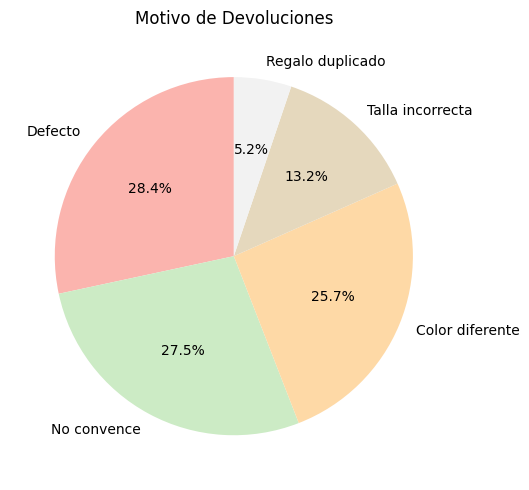

In [15]:
motivo_devolucion = devoluciones['motivo'].value_counts()
print(motivo_devolucion)
plt.figure(figsize=(10, 5))
motivo_devolucion.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title("Motivo de Devoluciones")
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insights:**
- Los motivos no están tan equilibrados ya que hay diferencias claras entre ellos:
- **Defecto (28.6%)** es el mas frecuente y ademas el más preocupante. Econtrol de calidad prioritario.
- **No convence (27.8%)** es el segundo mas frecuente, puede indicar que las fotos o descripciones del producto no representan bien el artículo.
- **Talla incorrecta (13.3%)** No es tan frecuente, lo que indicaría que las guías de tallas parecen funcionar razonablemente bien.
- **Regalo duplicado (5.2%)** Es el valor mas bajo, lo que significa que hay menos compras por regalo de lo esperado.
- **Recomendación:** Priorizar el control de calidad y mejorar las descripciones de producto.

## 6. Análisis de canales de venta

In [16]:
ventas_por_canal = tickets['canal'].value_counts() 
print(ventas_por_canal)
venta_total_canal = tickets.groupby('canal')['total'].sum()
print(venta_total_canal)

canal
tienda_fisica    17979
telefono          6015
online            6006
Name: count, dtype: int64
canal
online           1556855.77
telefono         1534225.83
tienda_fisica    4566284.89
Name: total, dtype: float64


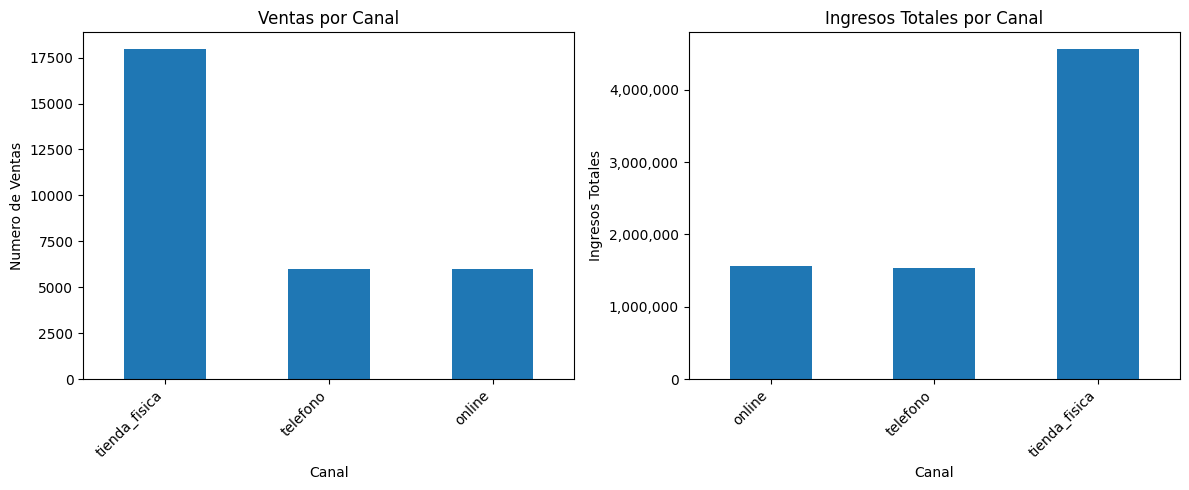

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ventas_por_canal.plot(kind='bar')
plt.title("Ventas por Canal")
plt.xlabel("Canal")
plt.ylabel("Numero de Ventas")
plt.xticks(rotation=45, ha='right')
plt.subplot(1, 2, 2)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
venta_total_canal.plot(kind='bar')
plt.title("Ingresos Totales por Canal")
plt.xlabel("Canal")
plt.ylabel("Ingresos Totales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
- La tienda física domina con 17,979 ventas y $4.5M en ingresos lo que es casi el triple que los canales digitales.
- Online y teléfono están muy igualados en ventas e ingresos y ninguno destaca sobre el otro.
- Los canales digitales representan una oportunidad de crecimiento significativa.
- **Recomendación:** Invertir en mejorar la experiencia digital: UX, promociones exclusivas online o app móvil podrían equilibrar la balanza con la tienda física.

## 7. Análisis explicativo — Patrones y tendencias

año   mes
2023  1      213893.72
      9      191637.15
2024  1      211301.33
      9      218601.06
2025  1      240066.32
      9      214887.00
Name: total, dtype: float64


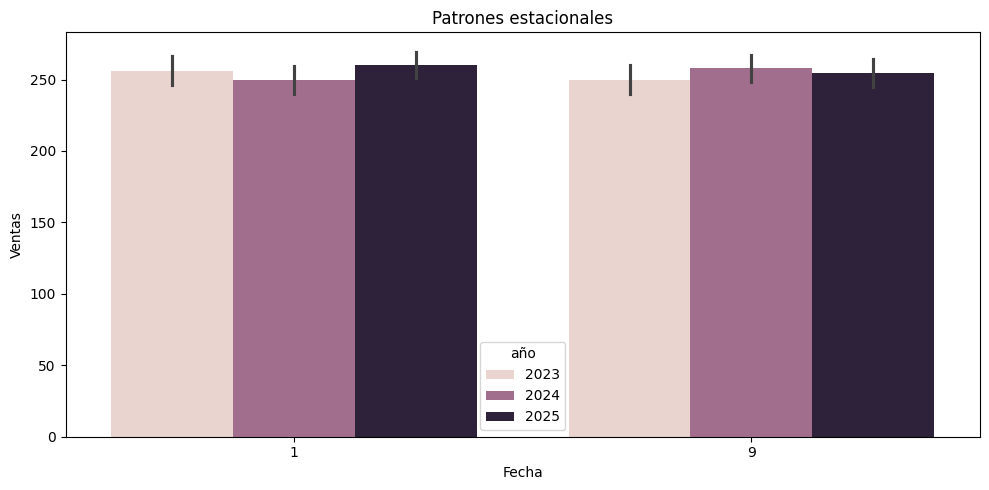

In [18]:
tickets['fecha'] = pd.to_datetime(tickets['fecha'])
tickets['mes'] = tickets['fecha'].dt.month
tickets['año'] = tickets['fecha'].dt.year
filtro = (tickets['mes'].isin([1, 9]))
tickets_filtrados = tickets[filtro]
ventas_especificas = tickets_filtrados.groupby(['año', 'mes'])['total'].sum()
print(ventas_especificas)

plt.figure(figsize=(10, 5))
sns.barplot(data=tickets_filtrados, x='mes', y='total', hue='año')
plt.title("Patrones estacionales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

**Insights — Análisis estacional:**
- Septiembre 2023 fue un evento puntual donde las ventas cayeron a 191,637, el mínimo del período.
- Septiembre 2024 y 2025 se recuperaron con normalidad (218,601 y 214,887)
- Enero muestra una tendencia creciente: 213,893 → 211,301 → 240,066
- No hay un patrón estacional claro por lo que las variaciones parecen aleatorias más que estacionales.

**INFLUENCIA PRECIO EN DEVOLUCIONES**

In [19]:
union_devoluciones = pd.merge(devoluciones, productos, left_on='producto_id', right_on='id')
print(f"Precio medio productos devueltos: {union_devoluciones['precio_venta'].mean():.2f}")
print(f"Precio medio todos los productos: {productos['precio_venta'].mean():.2f}")

Precio medio productos devueltos: 147.78
Precio medio todos los productos: 148.80


**Insights — ¿El precio influye en las devoluciones?**
- Precio medio productos devueltos: 147.78
- Precio medio todos los productos: 148.80
- La diferencia es practicamente inexistente (0.7%): El precio no es un factor determinante en las devoluciones, estas se distribuyen de forma similar independientemente del precio

**DIA DE LA SEMANA QUE MAS SE VENDE**

dia
Monday       1087385.70
Tuesday      1069479.95
Wednesday    1083856.12
Thursday     1094056.65
Friday       1112666.34
Saturday     1113072.00
Sunday       1096849.73
Name: total, dtype: float64


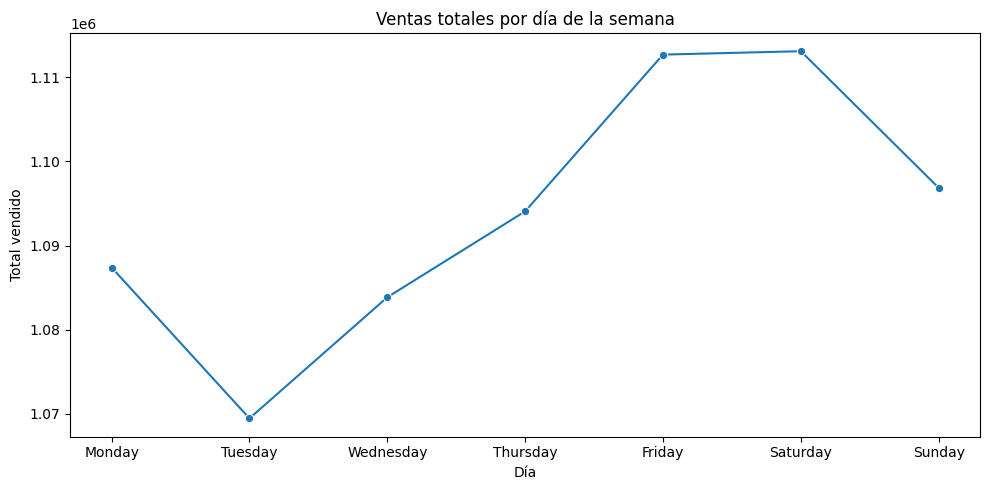

In [20]:
tickets['dia'] = tickets['fecha'].dt.day_name()
ventas_semanales = tickets.groupby('dia')['total'].sum()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_semanales = ventas_semanales.reindex(orden_dias)
print(ventas_semanales)
plt.figure(figsize=(10, 5))
sns.lineplot(x=ventas_semanales.index, y=ventas_semanales.values, marker='o')
plt.title("Ventas totales por día de la semana")
plt.xlabel("Día")
plt.ylabel("Total vendido")
plt.tight_layout()
plt.show()

**Insights — Ventas por día de la semana:**
- Viernes y sábado son los días de mayor venta, un comportamiento típico de comercio retail.
- Martes es el día más flojo, lo que presenta una interesante oportunidad de mejora.
- El resto de días están relativamente equilibrados.
- **Recomendación:** Implementar promociones específicas los martes para equilibrar las ventas semanales, por ejemplo, descuentos puntuales o envío gratuito ese día podrían aumentar el tráfico.

## 8. Machine Learning — Predicción de devoluciones

El objetivo es predecir si un producto será devuelto basándose en sus características: talla, color, temporada, precio y departamento.

In [21]:
devuelto = productos['devuelto'] = productos['id'].isin(devoluciones['producto_id']).astype(int)
devuelto = devuelto.value_counts()
print(devuelto)

id
1    392
0      8
Name: count, dtype: int64


In [22]:
ventas_por_producto = ticket_productos['producto_id'].value_counts()
devoluciones_por_producto = devoluciones['producto_id'].value_counts()
tasa_devolucion = devoluciones_por_producto.div(ventas_por_producto, fill_value=0)
umbral = tasa_devolucion.mean()
productos['alto_riesgo'] = (tasa_devolucion.reindex(productos['id']).fillna(0) > umbral).astype(int)
print(productos['alto_riesgo'].value_counts())


alto_riesgo
0.0    207
1.0    192
Name: count, dtype: int64


### Objetivo del modelo
El modelo va a detectar si un producto tiene mayor probabilidad de ser devuelto basándose en características como la temporada, talla o precio entre otras. Esto puede ayudar a detectar patrones y saber si un futuro producto tiene mayor posibilidad de ser devuelto antes de ser sacado al mercado, permitiendo actuar para evitar futuras devoluciones.

> **Nota:** Los datos son sintéticos por lo que al no ser reales contienen ciertas limitaciones que podrían llegar a afectar las predicciones del modelo. Los resultados deben interpretarse con cautela.

### Modelo seleccionado
Se utilizará **Random Forest** por su robustez con datos mixtos (categóricos y numéricos), su resistencia al sobreajuste y su capacidad de mostrar la importancia de cada variable, clave para interpretar qué características influyen más en las devoluciones.

In [26]:
productos_ml = pd.read_sql("SELECT * FROM productos_clean", engine)
productos_ml['alto_riesgo'] = (tasa_devolucion.reindex(productos_ml['id']).fillna(0) > umbral).astype(int)
categoricas = pd.get_dummies(productos_ml[['talla', 'color', 'temporada']], drop_first=True)
numericas = productos_ml[['precio_venta', 'precio_costo', 'departamento_id']]
X = pd.concat([categoricas, numericas], axis=1)
y = productos_ml['alto_riesgo']

In [27]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
mask = y.notna()
X = X[mask]
y = y[mask]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, min_samples_leaf=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.54
Precision: 0.65625
Recall: 0.375
F1 Score: 0.4772727272727273


### Optimización del modelo
#### Paso 1 — GridSearch para encontrar los mejores hiperparámetros

Vamos a optimizar el modelo para que priorice el Recall antes que la precision, ya que, en este caso concreto, es peor no detectar un producto que se va a devolver (falso negativo) que marcar como riesgo uno que no lo era (falso positivo)

In [31]:
from sklearn.model_selection import GridSearchCV
parametros = {
    'n_estimators': [50, 75, 100, 150],
    'max_depth': [None, 5, 8, 10, 20, 25],
    'min_samples_split': [2, 5, 10, 15, 20],
    'class_weight': ['balanced', {0: 1, 1: 5}]
}
grid = GridSearchCV(RandomForestClassifier(), parametros, scoring='recall', cv=5)
grid.fit(X_train, y_train)
print(f"Mejor recall: {grid.best_score_}")
print(f"Mejores parámetros: {grid.best_params_}")

Mejor recall: 0.9851851851851852
Mejores parámetros: {'class_weight': {0: 1, 1: 5}, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 75}


#### Paso 2 — Modelo optimizado con mejores hiperparámetros

In [32]:
param = {
    'n_estimators': 75,
    'max_depth': 5,
    'min_samples_split': 5,
    'class_weight': {0: 1, 1: 5}
}
mask = y.notna()
X = X[mask]
y = y[mask]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = RandomForestClassifier(random_state=42, **param)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.56
Precision: 0.5612244897959183
Recall: 0.9821428571428571
F1 Score: 0.7142857142857143


#### Resultados del modelo optimizado

La optimización mediante GridSearch ha conseguido una mejora muy significativa en nuestro objetivo principal: Detectar productos con alta probabilidad de devolución.

| Métrica  | Modelo base | Modelo optimizado |
|----------|-------------|-------------------|
| Accuracy |     54%     |       56%         |
| Precision|     65%     |       56%         |
| Recall   |    37.5%    |    **98.2%**      |
| F1 Score |     47%     |       71%         |

El modelo detecta correctamente el 98% de los productos de alto riesgo. Aunque genera algunos falsos positivos (precision 56%), esto no supone un problema para el negocio ya que es preferible revisar un producto que no se iba a devolver que dejar pasar uno que sí lo haría.

#### Paso 3 — Importancia de las variables

<Axes: ylabel='feature'>

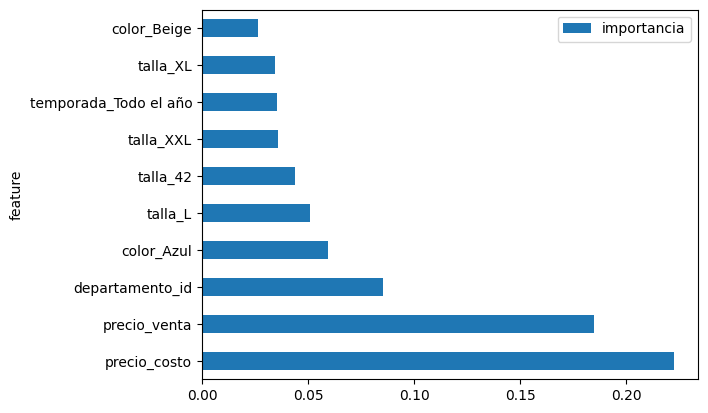

In [36]:
importancias = model.feature_importances_
importancia_df = pd.DataFrame({'feature': X_train.columns, 'importancia': importancias})
importancia_df = importancia_df.sort_values('importancia', ascending=False)
importancia_df.head(10).plot(kind='barh', x='feature', y='importancia')


#### Interpretación de las variables más importantes

- **Precio** domina claramente con `precio_costo` (22%) y `precio_venta` (18%); son los factores más determinantes en las devoluciones.
- **Departamento** (8.5%): la categoría del producto influye significativamente.
- **Talla XXL:** aparece entre las más importantes lo que confirma que las tallas extremas tienen más devoluciones.
- **Color Azul** destaca entre los colores; puede indicar que ciertos colores generan más expectativas que no se cumplen.

**Conclusión:** Los productos más caros y de tallas extremas tienen mayor riesgo de devolución, entonces, el negocio debería prestar especial atención a estos segmentos.

> **Nota técnica:** `precio_costo` y `precio_venta` están altamente correlacionados, lo que podría generar multicolinealidad. En un entorno de producción sería recomendable evaluar si eliminar `precio_costo` mejora la generalización del modelo.

## 9. Conclusiones y recomendaciones

### Ventas
- Las ventas se mantienen estables entre 190,000 y 240,000 mensuales sin tendencia clara de crecimiento
- Viernes y sábado son los días de mayor venta; martes el más flojo
- **Recomendación:** Implementar promociones los martes para equilibrar las ventas semanales

### Productos
- "Classic Cinturón" es el producto estrella: más vendido y más rentable
- Los accesorios y ropa básica dominan las ventas
- **Recomendación:** Potenciar la línea de accesorios y básicos

### Clientes
- El 20% de las ventas son anónimas lo que supone una oportunidad de captación
- Hay dos segmentos claros: clientes medios y clientes de alto valor
- **Recomendación:** Estrategia diferenciada para cada segmento

### Canales
- La tienda física genera casi el triple que los canales digitales
- Online y teléfono están igualados con margen de mejora
- **Recomendación:** Invertir en la experiencia digital

### Devoluciones y Machine Learning
- Defecto y No convence son los motivos principales de devolución
- El modelo predice productos de alto riesgo con un 98% de recall
- Los productos más caros y tallas extremas tienen mayor riesgo
- **Recomendación:** Control de calidad prioritario y mejorar descripciones de producto

### Limitaciones
- Los datos son sintéticos: Los resultados deben validarse con datos reales
- El modelo de ML mejorará significativamente con datos de negocio real